<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/PCA%20%C3%A9s%20TSNE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Főkomponens-elemzés (PCA) és t-SNE

A modern adatok gyakran **több száz vagy több ezer dimenziósak**: egy 28x28 pixeles fekete-fehér kép 784 dimenziós, egy genetikai mintán 20 000 gén kifejeződését mérjük, egy szöveg "bag-of-words" reprezentációja akár tízezer szavas. Ennyi dimenzióban:
- Nem tudjuk vizualizálni az adatot
- A modellek lassan tanulnak, és könnyen túlilleszkednek (curse of dimensionality)
- Az euklideszi távolság elveszti a megkülönböztető erejét

A **dimenziócsökkentés** célja: az eredeti adatból egy alacsonyabb dimenziós reprezentációt készíteni, amely megőrzi a *lényeges* struktúrát.

Ebben a notebookban két alapvető módszerrel ismerkedünk meg:
- **PCA**: lineáris, gyors, varianciát megőrző
- **t-SNE**: nemlineáris, lokális szerkezetre fókuszáló vizualizációs eszköz

## Tartalomjegyzék

1. A dimenziócsökkentés motivációja
2. Főkomponens-elemzés (PCA)
3. PCA implementáció lépésről lépésre
4. PCA gyakorlati alkalmazása
5. PCA korlátai
6. t-SNE algoritmus
7. t-SNE alkalmazása és összehasonlítás PCA-val

## 1. A dimenziócsökkentés motivációja

### Miért csökkentsük?

| Cél | Magyarázat |
|-----|------------|
| **Vizualizáció** | 2D vagy 3D-ben tudjuk megjeleníteni |
| **Zajcsökkentés** | Az alacsony varianciájú komponensek gyakran zajt tartalmaznak |
| **Tárolás és számítás** | Kevesebb dimenzió = gyorsabb gépi tanulás |
| **Túltanulás csökkentése** | Kevesebb paraméterre van szükség |
| **Manifold-feltevés** | A magas dimenziós adat gyakran egy alacsonyabb dimenziós felületre esik |

### Manifold hipotézis

A valós adatok ritkán töltik ki egyenletesen a teljes nagy dimenziós teret. Ehelyett egy **alacsonyabb dimenziós sokaságon** (manifold) helyezkednek el. Például az emberi arcok 3072-dimenziós (32x32x3) képeinek halmaza valójában jóval alacsonyabb dimenziós (változások a pózban, megvilágításban, korban stb.). A dimenziócsökkentés célja ennek a sokaságnak a felfedezése.

### Lineáris vs. nemlineáris

| Módszer | Típus | Mit őriz meg? |
|---------|-------|---------------|
| **PCA** | Lineáris | Globális variancia |
| **MDS** | Lineáris/nemlineáris | Páronkénti távolságok |
| **ISOMAP** | Nemlineáris | Geodetikus távolságok |
| **LLE** | Nemlineáris | Lokális szomszédsági viszonyok |
| **t-SNE** | Nemlineáris | Lokális hasonlósági viszonyok |
| **UMAP** | Nemlineáris | Lokális + globális topológia |

### Szükséges importok

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits, make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)

%matplotlib inline

## 2. Főkomponens-elemzés (PCA)

### Az alapötlet

A PCA olyan ortogonális tengelyeket keres, amelyek mentén az adat **varianciája maximális**. Az első főkomponens az a vonal, amelyre vetítve az adatpontok varianciája a legnagyobb; a második a maximális varianciájú irány az elsőre merőlegesek között; és így tovább.

### Matematikai megfogalmazás

Adott egy adatmátrix $X \in \mathbb{R}^{n \times d}$, ahol $n$ a minták száma, $d$ a dimenziók száma. **Centráljuk** az adatot:

$$\tilde{X} = X - \bar{X}$$

A **kovariancia mátrix**:

$$\Sigma = \frac{1}{n-1} \tilde{X}^T \tilde{X} \in \mathbb{R}^{d \times d}$$

A **főkomponensek** $\Sigma$ sajátvektorai, csökkenő sajátérték szerint:

$$\Sigma v_i = \lambda_i v_i, \quad \lambda_1 \geq \lambda_2 \geq ... \geq \lambda_d \geq 0$$

A $k$-dimenziós PCA-vetítés:

$$Z = \tilde{X} V_k, \quad V_k = [v_1 | v_2 | ... | v_k]$$

### Mit jelent a sajátérték?

A $\lambda_i$ sajátérték az $i$-edik főkomponens menti **variancia**. A megőrzött variancia aránya:

$$\text{megőrzött arány}(k) = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i}$$

### Kapcsolat az SVD-vel

Ha $\tilde{X} = U S V^T$ a centrált adat szinguláris érték felbontása, akkor:

$$\Sigma = \frac{1}{n-1} V S^2 V^T$$

vagyis $V$ oszlopai a főkomponensek, és $\lambda_i = s_i^2 / (n-1)$. A gyakorlatban az SVD numerikusan stabilabb, mint a kovariancia explicit kiszámítása.

## 3. PCA implementáció lépésről lépésre

Főkomponensek (sorai a komponensek):
[[ 0.74963723  0.66184894]
 [-0.66184894  0.74963723]]

Varianciák: [5.07309924 0.24130713]
Megőrzött arányok: [0.95459377 0.04540623]


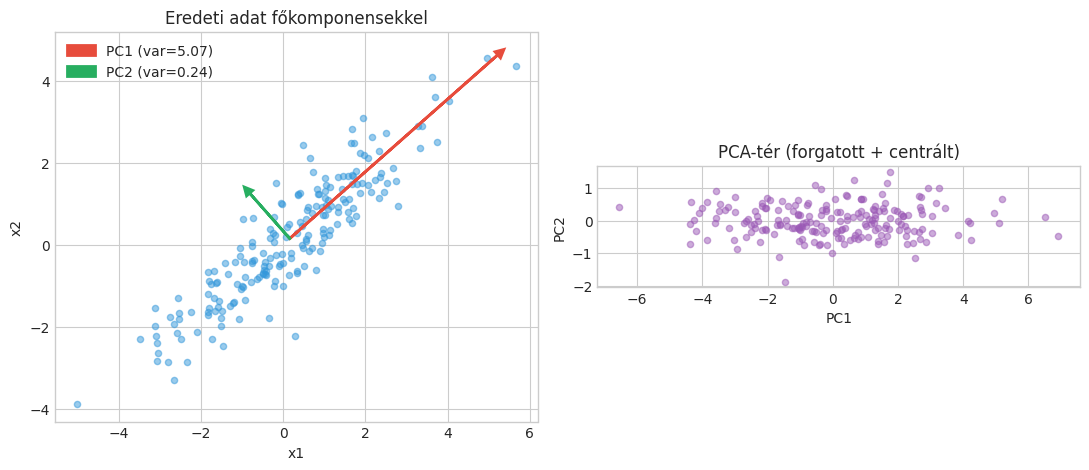

In [ ]:
class SimplePCA:
    """PCA implementáció SVD-vel."""

    def __init__(self, n_components):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None

    def fit(self, X):
        # 1. Centrálás
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        # 2. SVD: X = U S V^T
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

        # 3. Főkomponensek = V oszlopai (Vt sorai)
        self.components_ = Vt[:self.n_components]

        # 4. Megőrzött variancia
        n = X.shape[0]
        self.explained_variance_ = (S ** 2) / (n - 1)
        total_var = self.explained_variance_.sum()
        self.explained_variance_ratio_ = self.explained_variance_[:self.n_components] / total_var
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_


# Egyszerű 2D demo: korrelált adat
rng = np.random.default_rng(0)
N = 200
mean = [0, 0]
cov = [[3, 2.5], [2.5, 2.5]]
X2 = rng.multivariate_normal(mean, cov, N)

pca2 = SimplePCA(n_components=2).fit(X2)
print(f"Főkomponensek (sorai a komponensek):\n{pca2.components_}")
print(f"\nVarianciák: {pca2.explained_variance_}")
print(f"Megőrzött arányok: {pca2.explained_variance_ratio_}")

# Vizualizáció
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X2[:, 0], X2[:, 1], alpha=0.5, s=20, color='#3498db')
mean_x, mean_y = pca2.mean_
for i, (comp, var) in enumerate(zip(pca2.components_, pca2.explained_variance_)):
    scale = 3 * np.sqrt(var)
    axes[0].arrow(mean_x, mean_y, comp[0] * scale, comp[1] * scale,
                  head_width=0.2, head_length=0.2,
                  fc=['#e74c3c', '#27ae60'][i], ec=['#e74c3c', '#27ae60'][i],
                  linewidth=2, label=f'PC{i+1} (var={var:.2f})')
axes[0].set_aspect('equal')
axes[0].legend()
axes[0].set_title('Eredeti adat főkomponensekkel')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

Z2 = pca2.transform(X2)
axes[1].scatter(Z2[:, 0], Z2[:, 1], alpha=0.5, s=20, color='#9b59b6')
axes[1].set_aspect('equal')
axes[1].set_title('PCA-tér (forgatott + centrált)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

## 4. PCA gyakorlati alkalmazása

### Iris adathalmaz

A klasszikus 4-dimenziós Iris adat 3 osztállyal: bemutatjuk, hogy 2D-be vetítve is jól szétválaszthatók a fajok.

Iris PCA megőrzött variancia arányok:
  PC1: 0.730  (kumulatív: 0.730)
  PC2: 0.229  (kumulatív: 0.958)
  PC3: 0.037  (kumulatív: 0.995)
  PC4: 0.005  (kumulatív: 1.000)


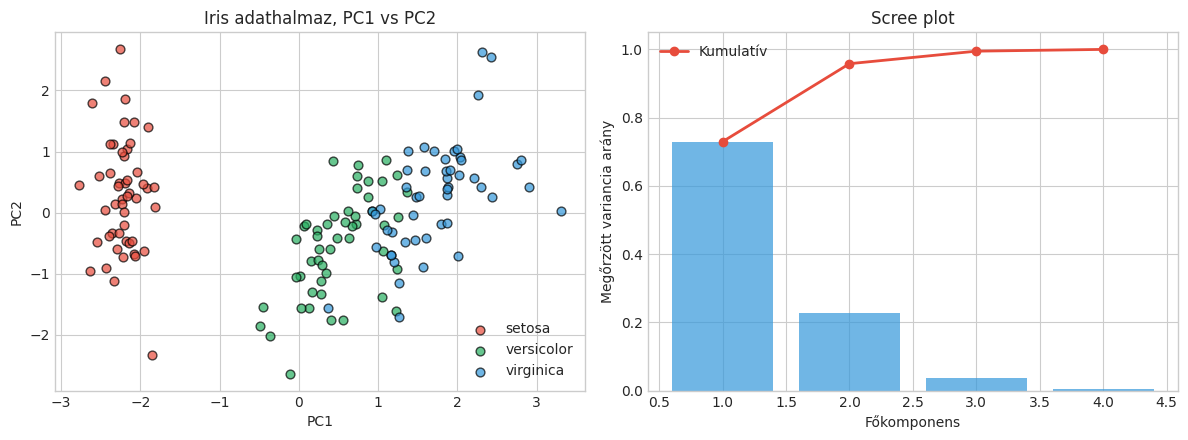

In [ ]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Standardizálás (különböző skálájú jellemzők)
X_iris_std = StandardScaler().fit_transform(X_iris)

# PCA 2D-re
pca_iris = PCA(n_components=4).fit(X_iris_std)
Z_iris = pca_iris.transform(X_iris_std)

print("Iris PCA megőrzött variancia arányok:")
for i, r in enumerate(pca_iris.explained_variance_ratio_):
    print(f"  PC{i+1}: {r:.3f}  (kumulatív: {pca_iris.explained_variance_ratio_[:i+1].sum():.3f})")

# Vizualizáció
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Scatter PC1-PC2
colors = ['#e74c3c', '#27ae60', '#3498db']
for cls in range(3):
    mask = y_iris == cls
    axes[0].scatter(Z_iris[mask, 0], Z_iris[mask, 1], c=colors[cls],
                    label=iris.target_names[cls], alpha=0.7, edgecolor='k', s=40)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Iris adathalmaz, PC1 vs PC2')
axes[0].legend()

# Scree plot
axes[1].bar(range(1, 5), pca_iris.explained_variance_ratio_, color='#3498db', alpha=0.7)
axes[1].plot(range(1, 5), pca_iris.explained_variance_ratio_.cumsum(),
             'o-', color='#e74c3c', linewidth=2, label='Kumulatív')
axes[1].set_xlabel('Főkomponens')
axes[1].set_ylabel('Megőrzött variancia arány')
axes[1].set_title('Scree plot')
axes[1].legend()

plt.tight_layout()
plt.show()

Számjegyek alakja: (1797, 64), osztályok: [0 1 2 3 4 5 6 7 8 9]
PC1+PC2 megőrzi a variancia 21.6%-át


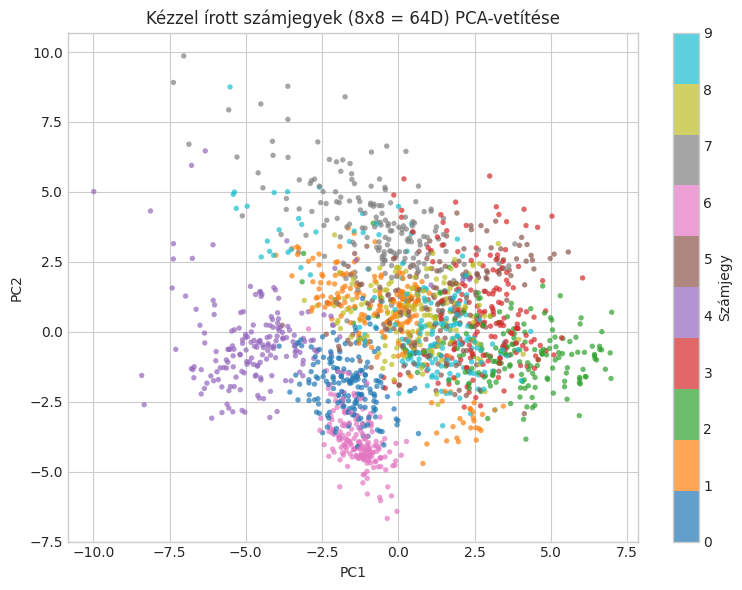

In [ ]:
# MNIST számjegyek: 64-dimenziós adat (8x8 képek)
digits = load_digits()
X_dig, y_dig = digits.data, digits.target
X_dig_std = StandardScaler().fit_transform(X_dig)

print(f"Számjegyek alakja: {X_dig.shape}, osztályok: {np.unique(y_dig)}")

pca_dig = PCA(n_components=2).fit(X_dig_std)
Z_dig = pca_dig.transform(X_dig_std)

print(f"PC1+PC2 megőrzi a variancia {pca_dig.explained_variance_ratio_.sum():.1%}-át")

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z_dig[:, 0], Z_dig[:, 1], c=y_dig, cmap='tab10',
                alpha=0.7, s=15, edgecolor='none')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Kézzel írott számjegyek (8x8 = 64D) PCA-vetítése')
plt.colorbar(sc, ax=ax, label='Számjegy')
plt.tight_layout()
plt.show()

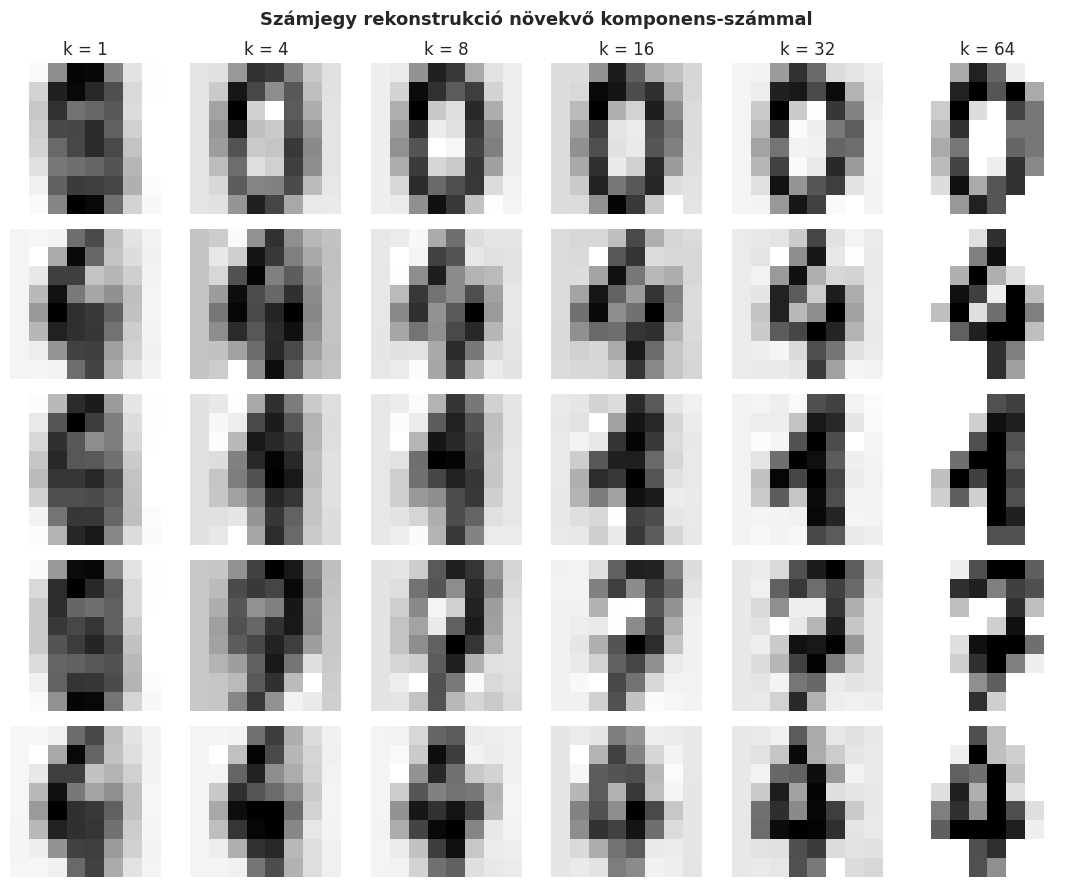

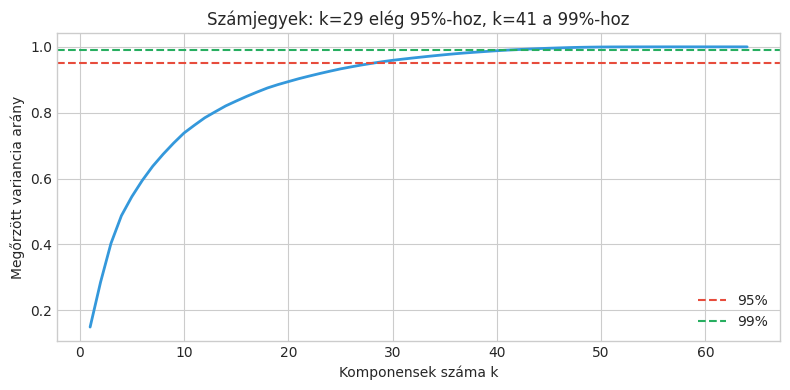

In [ ]:
# Rekonstruáljuk a számjegyeket különböző k-val
fig, axes = plt.subplots(5, 6, figsize=(11, 9))
ks = [1, 4, 8, 16, 32, 64]
sample_idx = [0, 100, 200, 300, 400]

for row, idx in enumerate(sample_idx):
    original = X_dig[idx].reshape(8, 8)
    for col, k in enumerate(ks):
        pca_k = PCA(n_components=k).fit(X_dig)
        Z = pca_k.transform(X_dig[idx:idx+1])
        recon = pca_k.inverse_transform(Z).reshape(8, 8)
        axes[row, col].imshow(recon, cmap='gray_r')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'k = {k}')

plt.suptitle('Számjegy rekonstrukció növekvő komponens-számmal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Variancia vs k
ks_full = list(range(1, 65))
ratios = [PCA(n_components=k).fit(X_dig).explained_variance_ratio_.sum() for k in ks_full]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks_full, ratios, color='#3498db', linewidth=2)
ax.axhline(0.95, color='#e74c3c', linestyle='--', label='95%')
ax.axhline(0.99, color='#27ae60', linestyle='--', label='99%')
k95 = next(i for i, r in zip(ks_full, ratios) if r >= 0.95)
k99 = next(i for i, r in zip(ks_full, ratios) if r >= 0.99)
ax.set_xlabel('Komponensek száma k')
ax.set_ylabel('Megőrzött variancia arány')
ax.set_title(f'Számjegyek: k={k95} elég 95%-hoz, k={k99} a 99%-hoz')
ax.legend()
plt.tight_layout()
plt.show()

## 5. PCA korlátai

### Linearitás

A PCA csak **lineáris** kombinációkat keres. Ha az adat egy görbült sokaságon helyezkedik el (pl. egy "Swiss roll"), a PCA összegyűri.

### Klasszikus ellenpélda: Swiss roll

Egy 3D-be tekert 2D papírlap. A PCA a vetített 2D-ben elveszti a topológiát: olyan pontok kerülnek egymás mellé, amelyek a sokaság mentén távol vannak.

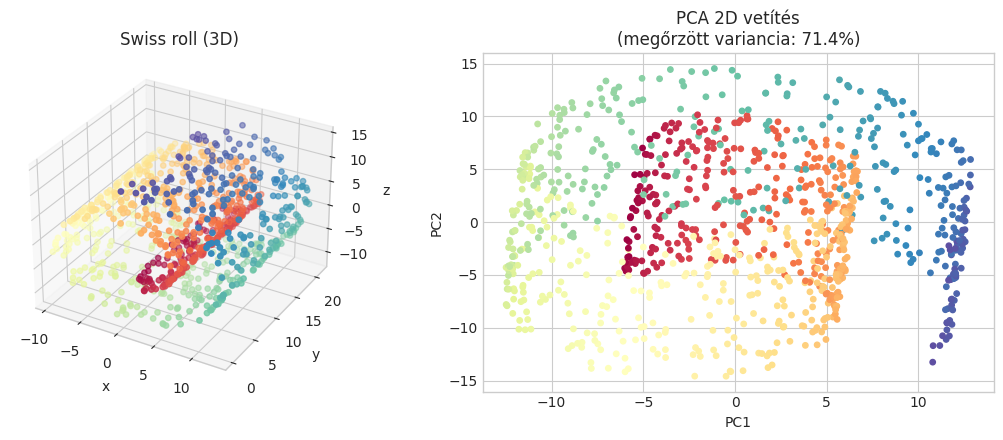

In [ ]:
# Swiss roll: nemlineáris sokaság
X_sr, color_sr = make_swiss_roll(n_samples=1000, noise=0.1, random_state=0)

# PCA 2D-re
pca_sr = PCA(n_components=2)
Z_sr = pca_sr.fit_transform(X_sr)

fig = plt.figure(figsize=(11, 4.5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_sr[:, 0], X_sr[:, 1], X_sr[:, 2], c=color_sr, cmap='Spectral', s=15)
ax1.set_title('Swiss roll (3D)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(122)
ax2.scatter(Z_sr[:, 0], Z_sr[:, 1], c=color_sr, cmap='Spectral', s=15)
ax2.set_title(f'PCA 2D vetítés\n(megőrzött variancia: {pca_sr.explained_variance_ratio_.sum():.1%})')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

## 6. t-SNE algoritmus

A **t-Distributed Stochastic Neighbor Embedding** (van der Maaten & Hinton, 2008) nemlineáris, **lokális** szerkezetre fókuszáló módszer. A célja: hasonló pontok a magas dimenziós térben legyenek hasonlók az alacsony dimenziósban is.

### Az ötlet

1. Definiáljunk páronkénti **hasonlóságokat** $p_{ij}$ a magas dimenziós térben (Gauss-eloszlás alapján)
2. Definiáljunk páronkénti hasonlóságokat $q_{ij}$ az alacsony dimenziós térben (Student-t eloszlás)
3. Minimalizáljuk a **KL-divergenciát** $p$ és $q$ között gradient descent-tel

### Magas dimenziós hasonlóság

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

A $\sigma_i$-t a **perplexity** paraméter alapján határozzuk meg pontonként:

$$\text{Perp}(P_i) = 2^{-\sum_j p_{j|i} \log_2 p_{j|i}}$$

A perplexitás durván a "szomszédok várható számát" jelenti. Tipikus értékek: $5$ és $50$ között.

### Alacsony dimenziós hasonlóság

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}$$

Student-t (Cauchy) eloszlás. Vastagabb farkú, mint a Gauss, így a **csoportok közötti taszítás** erősebb, ami nyitottabb klasztereket ad.

### Veszteségfüggvény

$$\mathcal{L} = \text{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Ezt $y_1, ..., y_n$ szerint minimalizáljuk.

### Fontos: a t-SNE NEM őrzi meg a globális távolságokat

A klaszterek közötti **távolságok és méretek** nem értelmezhetők a t-SNE-ben. Csak a *közeli pontok közelsége* releváns.

t-SNE futtatása (kis lehet 10-30 másodperc)...
  Idő: 15.8 s


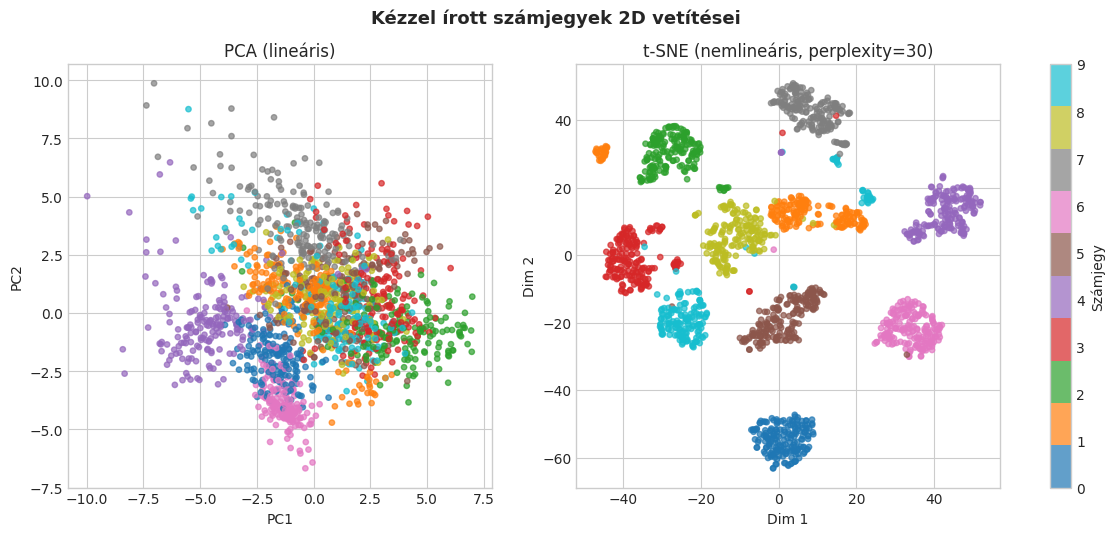

In [ ]:
# t-SNE számjegyekre
print("t-SNE futtatása (kis lehet 10-30 másodperc)...")
t0 = time.perf_counter()
tsne_dig = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                init='pca', random_state=0)
Z_tsne = tsne_dig.fit_transform(X_dig)
print(f"  Idő: {time.perf_counter() - t0:.1f} s")

# PCA vs t-SNE oldalt
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sc1 = axes[0].scatter(Z_dig[:, 0], Z_dig[:, 1], c=y_dig, cmap='tab10',
                      alpha=0.7, s=15)
axes[0].set_title(f'PCA (lineáris)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

sc2 = axes[1].scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=y_dig, cmap='tab10',
                      alpha=0.7, s=15)
axes[1].set_title(f't-SNE (nemlineáris, perplexity=30)')
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')

plt.colorbar(sc2, ax=axes, label='Számjegy', fraction=0.025)
plt.suptitle('Kézzel írott számjegyek 2D vetítései', fontsize=13, fontweight='bold')
plt.show()

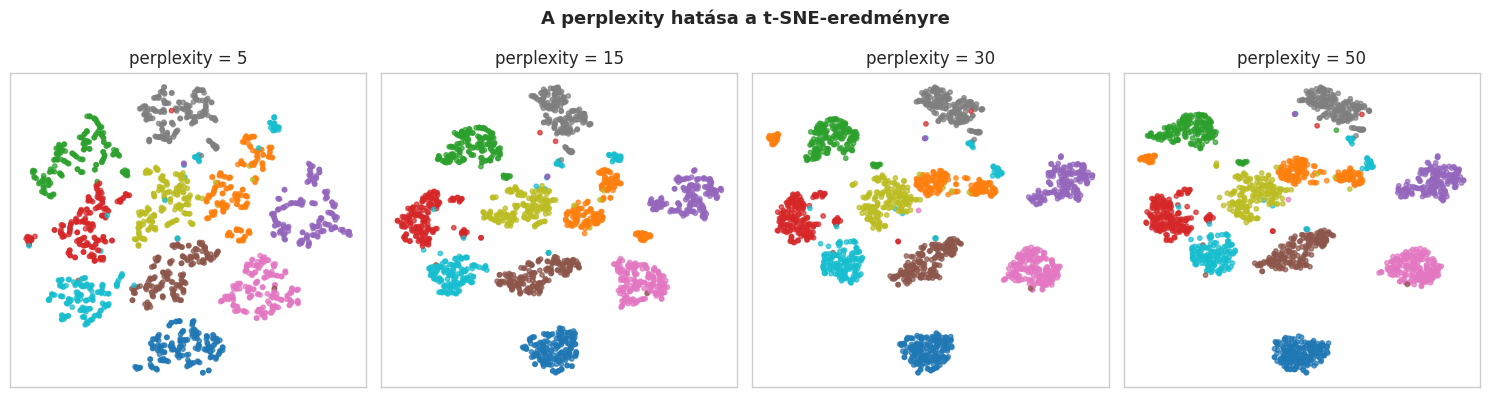

In [ ]:
# A perplexity hatása
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate='auto',
                init='pca', random_state=0)
    Z = tsne.fit_transform(X_dig)
    ax.scatter(Z[:, 0], Z[:, 1], c=y_dig, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f'perplexity = {perp}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('A perplexity hatása a t-SNE-eredményre', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. PCA vs t-SNE összehasonlítás

| Szempont | PCA | t-SNE |
|----------|-----|-------|
| **Linearitás** | Lineáris | Nemlineáris |
| **Számítási költség** | Gyors, $O(\min(nd^2, n^2 d))$ | Lassú, $O(n^2)$ vagy $O(n \log n)$ Barnes-Hut-tal |
| **Determinisztikus** | Igen | Nem (véletlen inicializálás) |
| **Skálázható új adatra** | Igen, $X_{\text{új}} V_k$ | Nem (újra kell futtatni) |
| **Globális struktúra** | Megőrzi | NEM őrzi meg |
| **Lokális struktúra** | Csak a varianciát érintőt | Erősen megőrzi |
| **Vizualizáció** | OK | Kiváló |
| **Adatcsökkentés ML-hez** | Igen | Nem ajánlott |

### Mikor melyiket?

| Cél | Választás |
|-----|-----------|
| Adat előfeldolgozása ML modellhez | PCA |
| Magas dimenziós tér megértése, klaszterek vizualizálása | t-SNE (vagy UMAP) |
| Zajcsökkentés | PCA |
| Manifold-hipotézis vizsgálata | t-SNE / UMAP / ISOMAP |
| Online / streaming feldolgozás | PCA (incremental PCA) |

### Mire vigyázzunk t-SNE-nél?

1. A klaszterek **mérete** és **távolsága** nem értelmes
2. Az eredmény változik más random seed mellett
3. A perplexity erősen befolyásolja a kimenetet
4. Csak vizualizációra használjuk; ne ML pipeline közbülső lépésére

n       PCA (s)     t-SNE (s)   arány     
---------------------------------------------
100     0.0049      0.708       146       x
300     0.0048      3.092       650       x
1000    0.0028      13.912      4882      x
1500    0.0048      27.996      5872      x


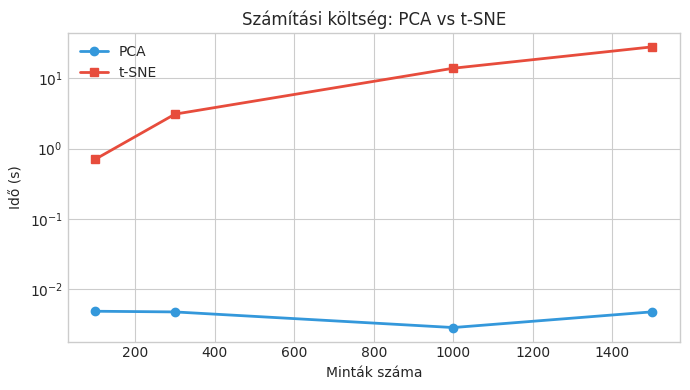

In [ ]:
# Időmérés: PCA vs t-SNE
sizes = [100, 300, 1000, 1500]
times_pca, times_tsne = [], []

for n in sizes:
    idx = np.random.choice(len(X_dig), n, replace=False)
    Xs = X_dig[idx]

    t0 = time.perf_counter()
    PCA(n_components=2).fit_transform(Xs)
    times_pca.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    TSNE(n_components=2, perplexity=min(30, n // 4),
         init='pca', learning_rate='auto', random_state=0).fit_transform(Xs)
    times_tsne.append(time.perf_counter() - t0)

print(f"{'n':<8}{'PCA (s)':<12}{'t-SNE (s)':<12}{'arány':<10}")
print('-' * 45)
for n, p, t in zip(sizes, times_pca, times_tsne):
    print(f"{n:<8}{p:<12.4f}{t:<12.3f}{t / max(p, 1e-6):<10.0f}x")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, times_pca, 'o-', label='PCA', color='#3498db', linewidth=2)
ax.plot(sizes, times_tsne, 's-', label='t-SNE', color='#e74c3c', linewidth=2)
ax.set_xlabel('Minták száma')
ax.set_ylabel('Idő (s)')
ax.set_title('Számítási költség: PCA vs t-SNE')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## PCA dióhéjban

1. Centráld az adatot
2. Számítsd ki a kovariancia mátrixot vagy SVD-t
3. Tartsd meg a $k$ legnagyobb sajátértékhez tartozó főkomponenseket
4. Vetítsd az adatot ezekre

**Erősségek**: gyors, determinisztikus, megfordítható, ML pipeline-okba illik
**Gyengeségek**: csak lineáris struktúrát talál

### t-SNE dióhéjban

1. Magas dimenzióban Gauss-alapú $p_{ij}$ hasonlóságok (perplexity vezérli a $\sigma$-t)
2. Alacsony dimenzióban Student-t alapú $q_{ij}$
3. Minimalizáld $\text{KL}(p \| q)$-t gradient descent-tel

**Erősségek**: nemlineáris, lokális struktúrát kiválóan vizualizál
**Gyengeségek**: lassú, sztochasztikus, nem skálázható új adatra, globális struktúrát nem őrzi

## Gyakorló feladatok

### 1. feladat

Bizonyítsd be, hogy a PCA első főkomponense $v_1$ az **iránymutatóként** maximalizálja a vetített variancia $\text{Var}(\tilde{X} v) = v^T \Sigma v$-t a $\|v\| = 1$ kényszer mellett.

<details>
<summary><strong>Megoldás megjelenítése</strong></summary>

Lagrange multiplikátorral:

$$\mathcal{L}(v, \lambda) = v^T \Sigma v - \lambda (v^T v - 1)$$

Deriválva $v$ szerint és nullára állítva:

$$\Sigma v = \lambda v$$

Tehát $v$ sajátvektora $\Sigma$-nak. A vetített variancia $v^T \Sigma v = \lambda v^T v = \lambda$, vagyis a maximumot a **legnagyobb sajátérték** adja, és a hozzá tartozó sajátvektor a maximalizáló irány.

</details>

### 2. feladat

Egy adathalmazon a PCA után az első három főkomponens megőrzött variancia aránya $0.62, 0.21, 0.10$. Ha az adat eredetileg 50 dimenziós, hány dimenzióra van szükség a 95%-os megőrzéshez (legrosszabb esetben)?

<details>
<summary><strong>Megoldás megjelenítése</strong></summary>

Az első 3 komponens megőriz $0.62 + 0.21 + 0.10 = 0.93$-at, tehát még 2% kell.

A maradék 47 komponens megőrzi a maradék 7%-ot. Legrosszabb esetben (egyenletes eloszlás) komponensenként $7\%/47 \approx 0.15\%$. A 2% további megőrzéséhez kb. $\lceil 2/0.15 \rceil = 14$ további komponens kellene.

Összesen tehát **legfeljebb $3 + 14 = 17$** komponens.

A gyakorlatban a fennmaradó variancia gyorsabban csökken (Pareto-szerű), így általában jóval kevesebb is elég.

</details>

### 3. feladat

Egy diákod azt javasolja, hogy a t-SNE-vel csökkentsen 50 dimenzióból 10 dimenzióra, majd egy klasszifikátort tanítson rá. Mi a probléma ezzel az ötlettel?

<details>
<summary><strong>Megoldás megjelenítése</strong></summary>

Több probléma is van:

1. **t-SNE nem skálázható új adatra**: a teszt halmaz pontjait nem tudjuk a már meglévő vetületbe ágyazni. Vagy újrafuttatjuk az egészet, vagy közelítő módszerhez folyamodunk.

2. **t-SNE célja a vizualizáció**, nem ML pipeline. A `n_components=10` ritkán használt; a Student-t eloszlás nem skálázódik jól magas dimenzióban.

3. **A távolságok nem értelmezhetők**: a t-SNE térben a távolságok nem felelnek meg semmilyen természetes metrikának, így a klasszifikátor (pl. KNN) félrevezető eredményt ad.

**Helyes megközelítés**: használj PCA-t (vagy autoencoder-t) ML pipeline-ban. t-SNE-t csak vizualizációra.

</details>